### PV estimations

First step: inspect the raw PV ramp data before calculating any EMS values.

#### Load and inspect the raw PV data

This cell reads all PV ramp files, applies the same INA3 PV sensor correction as the larger analysis script, and plots the corrected PV voltage, current, and power. The goal is only to check if the data looks reasonable.

In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt


DATA_DIR = Path("../../data/PV_test/New_test")

# PV panel is measured by INA3 / address 0x44.
# These correction factors come from the sensor calibration.
PV_VOLTAGE_CORRECTION = lambda v: v - 0.180
PV_CURRENT_CORRECTION = lambda i: i + 0.000138


def get_distance_cm(file_name):
    match = re.search(r"PV_0?(\d+)cm", file_name)
    return int(match.group(1))


def load_pv_file(path):
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)

    df["time_s"] = (
        df["timestamp"] - df["timestamp"].iloc[0]
    ).dt.total_seconds()

    df["pv_voltage_V"] = PV_VOLTAGE_CORRECTION(df["ina3_bus_V"])
    df["pv_current_A"] = PV_CURRENT_CORRECTION(df["ina3_current_mA"] / 1000)

    # Formula: P [mW] = V [V] * I [A] * 1000
    df["pv_power_mW"] = df["pv_voltage_V"] * df["pv_current_A"] * 1000

    return df


pv_files = sorted(DATA_DIR.glob("PV_*cm_ramp.csv"))

print("PV ramp files:")
for file in pv_files:
    print(" -", file.name)


pv_data = {}

for file in pv_files:
    distance_cm = get_distance_cm(file.name)
    df = load_pv_file(file)
    pv_data[distance_cm] = df

    print(f"\n{file.name}")
    print("Rows:", len(df))
    print("Time:", df["time_s"].min(), "to", df["time_s"].max(), "s")
    print("Voltage:", df["pv_voltage_V"].min(), "to", df["pv_voltage_V"].max(), "V")
    print("Current:", df["pv_current_A"].min(), "to", df["pv_current_A"].max(), "A")
    print("Power:", df["pv_power_mW"].min(), "to", df["pv_power_mW"].max(), "mW")


display(pv_data[1].head())

PV ramp files:
 - PV_01cm_ramp.csv
 - PV_05cm_ramp.csv
 - PV_10cm_ramp.csv
 - PV_15cm_ramp.csv
 - PV_20cm_ramp.csv

PV_01cm_ramp.csv
Rows: 151
Time: 0.0 to 158.0 s
Voltage: 0.09129999999999999 to 4.4112 V
Current: 3.799999999999999e-05 to 0.11221300000000001 A
Power: 0.16596499999999997 to 379.788465 mW

PV_05cm_ramp.csv
Rows: 145
Time: 0.0 to 152.0 s
Voltage: 0.0938 to 4.3212 V
Current: 3.799999999999999e-05 to 0.111938 A
Power: 0.16411439999999997 to 344.81420999999995 mW

PV_10cm_ramp.csv
Rows: 129
Time: 0.0 to 135.0 s
Voltage: 0.0363 to 4.1000000000000005 V
Current: 3.799999999999999e-05 to 0.09911299999999999 A
Power: 0.15565559999999998 to 291.99064 mW

PV_15cm_ramp.csv
Rows: 96
Time: 0.0 to 100.0 s
Voltage: -0.0388 to 4.0225 V
Current: 3.799999999999999e-05 to 0.070063 A
Power: -2.6971044 to 203.76167940000002 mW

PV_20cm_ramp.csv
Rows: 77
Time: 0.0 to 80.0 s
Voltage: -0.0812 to 3.9599999999999995 V
Current: 3.799999999999999e-05 to 0.055963 A
Power: -4.503595600000001 to 159.12

,timestamp,scenario,mode,K1,K2,K3,K4,K5,K6,K7,...,ina3_shunt_mV,ina4_ok,ina4_bus_V,ina4_current_mA,ina4_power_mW,ina4_shunt_mV,time_s,pv_voltage_V,pv_current_A,pv_power_mW
0,2026-04-30 12:33:15,4,Scenario 4: PV -> Load,0,1,1,1,1,1,0,...,-0.0075,1,0.1637,-0.050,0.0,-0.0050,0.0,4.4100,0.000063,0.277830
1,2026-04-30 12:33:16,4,Scenario 4: PV -> Load,0,1,1,1,1,1,0,...,-0.0075,1,0.1637,-0.075,0.0,-0.0075,1.0,4.4112,0.000063,0.277906
2,2026-04-30 12:33:17,4,Scenario 4: PV -> Load,0,1,1,1,1,1,0,...,-0.0075,1,0.1650,-0.050,0.0,-0.0050,2.0,4.4087,0.000063,0.277748
3,2026-04-30 12:33:18,4,Scenario 4: PV -> Load,0,1,1,1,1,1,0,...,-0.0100,1,0.1637,-0.050,0.0,-0.0050,3.0,4.4050,0.000038,0.167390
4,2026-04-30 12:33:19,4,Scenario 4: PV -> Load,0,1,1,1,1,1,0,...,-0.0075,1,0.1650,-0.050,0.0,-0.0050,4.0,4.4075,0.000063,0.277673


#### Plot the corrected raw PV curves

These plots are just for visual checking. The different distances represent different light intensities.

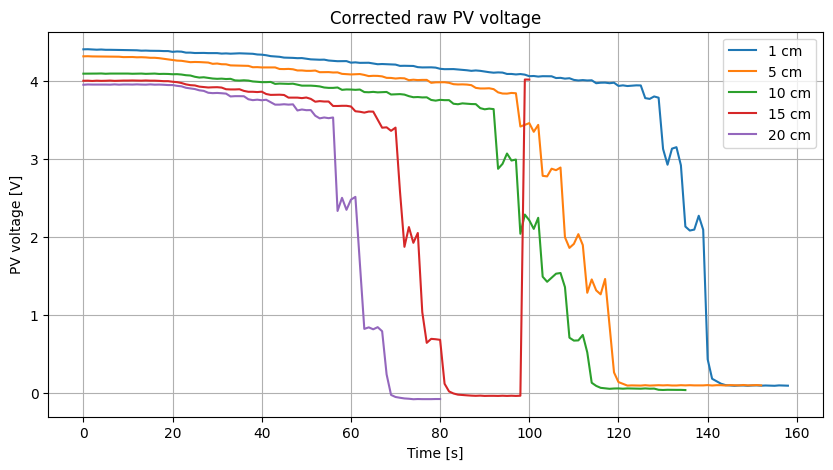

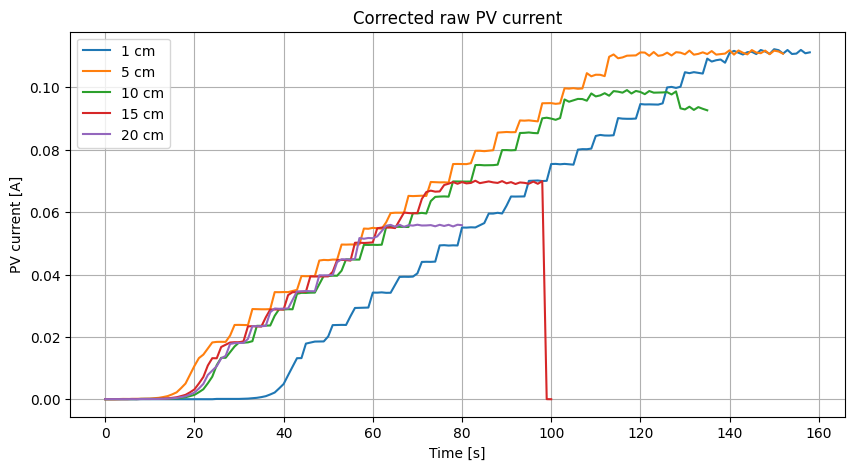

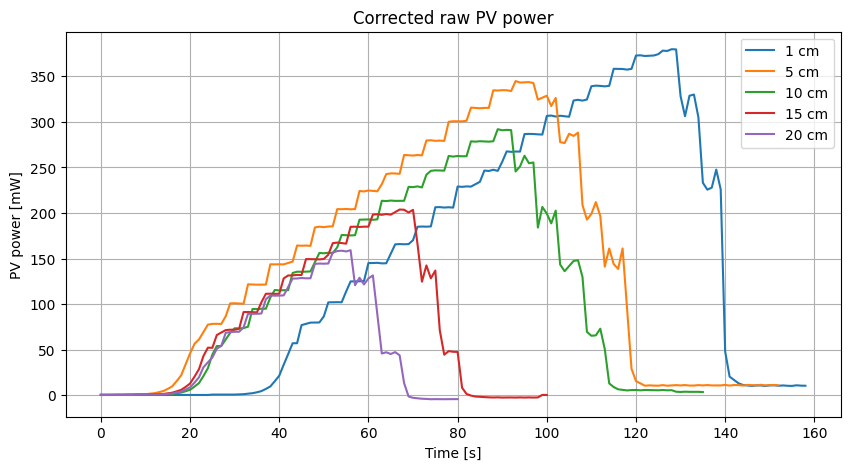

In [2]:
plt.figure(figsize=(10, 5))

for distance_cm, df in pv_data.items():
    plt.plot(df["time_s"], df["pv_voltage_V"], label=f"{distance_cm} cm")

plt.xlabel("Time [s]")
plt.ylabel("PV voltage [V]")
plt.title("Corrected raw PV voltage")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))

for distance_cm, df in pv_data.items():
    plt.plot(df["time_s"], df["pv_current_A"], label=f"{distance_cm} cm")

plt.xlabel("Time [s]")
plt.ylabel("PV current [A]")
plt.title("Corrected raw PV current")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))

for distance_cm, df in pv_data.items():
    plt.plot(df["time_s"], df["pv_power_mW"], label=f"{distance_cm} cm")

plt.xlabel("Time [s]")
plt.ylabel("PV power [mW]")
plt.title("Corrected raw PV power")
plt.grid(True)
plt.legend()
plt.show()